# 1. 길이 및 구조 (Structure) 분석

이 단계에서는 대화 데이터의 물리적 구조를 파악합니다. 특히 클래스별로 대화의 길이나 발화 횟수의 차이가 있는지 확인하여, 모델이 '내용'이 아닌 '길이'라는 단순 수치에 편향(Bias)되는 것을 방지하는 전략을 세웁니다.

[1-1] 문장/단어 길이 분포 분석


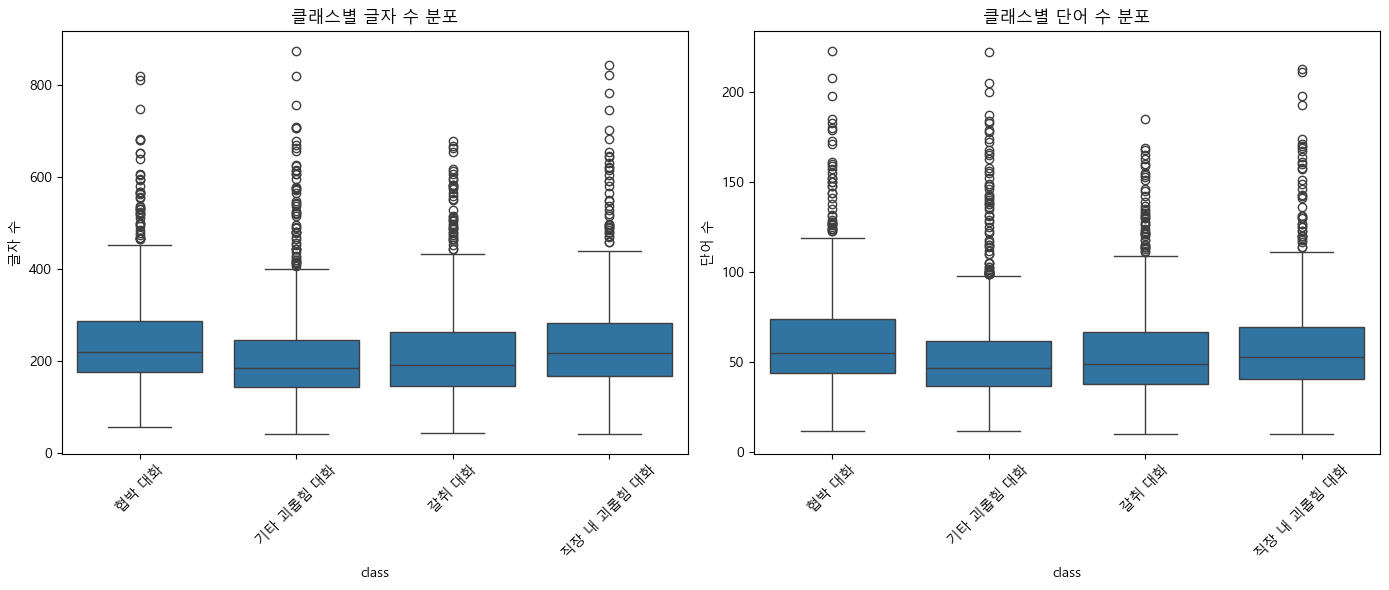


### [1-1] 클래스별 길이 통계 요약 ###


char_len                 word_len                
                mean median min  max     mean median min  max
class                                                        
갈취 대화          216.2  191.0  45  678     55.5   49.0  10  185
기타 괴롭힘 대화      210.1  185.0  41  874     53.2   47.0  12  222
직장 내 괴롭힘 대화    237.6  217.0  41  843     58.5   53.0  10  213
협박 대화          246.1  220.0  57  818     62.0   55.0  12  223


### [1-1 인사이트 및 Action Item] ###
1. 특정 클래스만 글자 수/단어 수가 유독 길거나 짧다면, 길이에 의한 편향(Bias)이 발생할 수 있습니다.
2. 글자 수 대비 단어 수가 적다면(어휘 밀도↑), 특정 말투/단어가 반복되는지 점검이 필요합니다.
3. 합성 데이터(일반 대화) 생성 시, 이 통계 범위 안에서 길이를 조절하세요.

[1-2] 대화 발화 횟수 (Turns) 분석


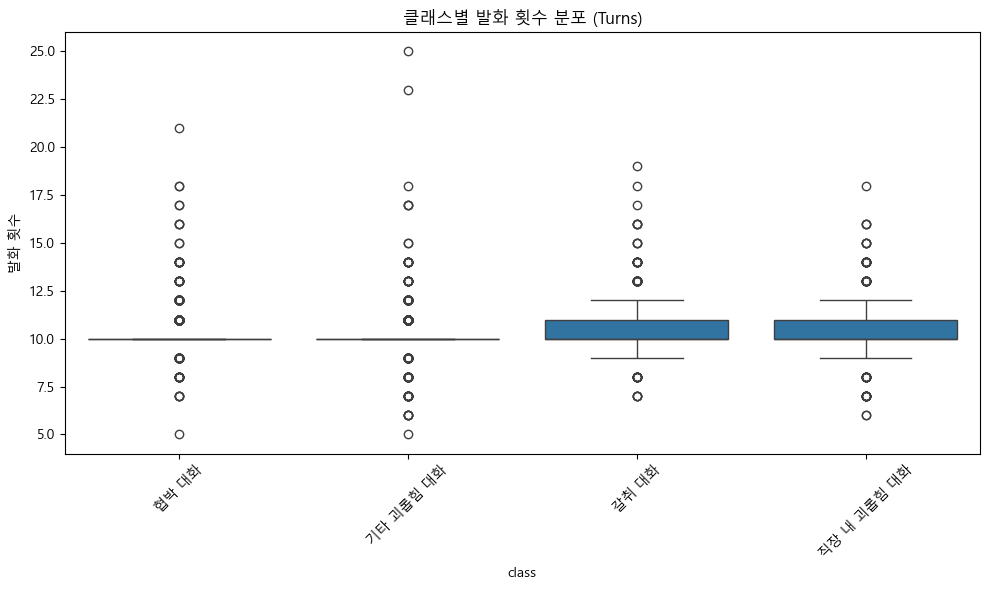


### [1-2] 클래스별 발화 횟수 통계 요약 ###


,mean,median,min,max
class,,,,
갈취 대화,10.5,10.0,7,19
기타 괴롭힘 대화,10.2,10.0,5,25
직장 내 괴롭힘 대화,10.4,10.0,6,18
협박 대화,10.3,10.0,5,21



### [1-2 인사이트 및 Action Item] ###
1. 특정 클래스만 발화 횟수가 유독 많거나 적은지 확인하세요.
2. 합성 데이터 생성 시, 모델이 학습할 적절한 '대화의 호흡'을 이 중간값 수준으로 설정하는 것이 안전합니다.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
train_df = pd.read_csv('train.csv')

# ============================================================
# 1. 길이 및 구조 (Structure) 분석
# ============================================================
# 대화 데이터의 물리적 구조를 파악합니다.
# 클래스별로 길이나 발화 횟수의 차이가 있는지 확인하여,
# 모델이 '내용'이 아닌 '길이'에 편향되는 것을 방지하는 전략을 세웁니다.

def analyze_structure(df):
    """대화 데이터의 구조적 특징을 파생하는 함수"""
    df['char_len'] = df['conversation'].apply(len)
    df['word_len'] = df['conversation'].apply(lambda x: len(x.split()))
    df['turn_count'] = df['conversation'].apply(
        lambda x: len([s for s in x.split('\n') if s.strip()])
    )
    return df

df = analyze_structure(train_df)

# ============================================================
# [1-1] 문장/단어/토큰 길이 분포
# eda.md: "클래스별 평균/중간값/최대·최소 길이 확인"
# ============================================================
print("=" * 60)
print("[1-1] 문장/단어 길이 분포 분석")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='class', y='char_len', data=df, ax=axes[0])
axes[0].set_title('클래스별 글자 수 분포')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('글자 수')

sns.boxplot(x='class', y='word_len', data=df, ax=axes[1])
axes[1].set_title('클래스별 단어 수 분포')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('단어 수')

plt.tight_layout()
plt.show()

# 통계 요약: 평균 / 중간값 / 최대 / 최소
print("\n### [1-1] 클래스별 길이 통계 요약 ###")
len_stats = df.groupby('class')[['char_len', 'word_len']].agg(
    ['mean', 'median', 'min', 'max']
).round(1)
display(len_stats)

print("\n### [1-1 인사이트 및 Action Item] ###")
print("1. 특정 클래스만 글자 수/단어 수가 유독 길거나 짧다면, 길이에 의한 편향(Bias)이 발생할 수 있습니다.")
print("2. 글자 수 대비 단어 수가 적다면(어휘 밀도↑), 특정 말투/단어가 반복되는지 점검이 필요합니다.")
print("3. 합성 데이터(일반 대화) 생성 시, 이 통계 범위 안에서 길이를 조절하세요.")

# ============================================================
# [1-2] 대화 발화 횟수 (Turns)
# eda.md: "하나의 대화당 몇 번의 발화가 일어나는지 통계"
# ============================================================
print("\n" + "=" * 60)
print("[1-2] 대화 발화 횟수 (Turns) 분석")
print("=" * 60)

plt.figure(figsize=(10, 6))
sns.boxplot(x='class', y='turn_count', data=df)
plt.title('클래스별 발화 횟수 분포 (Turns)')
plt.tick_params(axis='x', rotation=45)
plt.ylabel('발화 횟수')
plt.tight_layout()
plt.show()

# 통계 요약: 평균 / 중간값 / 최대 / 최소
print("\n### [1-2] 클래스별 발화 횟수 통계 요약 ###")
turn_stats = df.groupby('class')['turn_count'].agg(
    ['mean', 'median', 'min', 'max']
).round(1)
display(turn_stats)

print("\n### [1-2 인사이트 및 Action Item] ###")
print("1. 특정 클래스만 발화 횟수가 유독 많거나 적은지 확인하세요.")
print("2. 합성 데이터 생성 시, 모델이 학습할 적절한 '대화의 호흡'을 이 중간값 수준으로 설정하는 것이 안전합니다.")


# 2. 어휘 및 키워드 (Vocabulary) 분석

이 단계에서는 각 클래스를 대표하는 핵심 어휘와 단어의 조합(N-gram)을 분석합니다. 이를 통해 모델이 특정 단어에 과도하게 의존하는지 확인하고, 향후 '일반 대화' 합성 데이터 생성 시 클래스 간의 변별력을 높일 수 있는 단어 리스트를 확보합니다.

* **TF-IDF 상위 키워드**: 단순 빈도수(Count)의 한계를 넘어, 특정 클래스에서만 유독 중요하게 정류되는 단어를 추출합니다.
* **N-gram 분석**: '돈'이라는 단어 단독보다는 '돈 내놔', '돈 빌려'와 같은 연쇄적인 패턴을 파악합니다.
* **어휘 다양성(TTR)**: 각 클래스가 얼마나 다양한 표현을 쓰는지, 혹은 정형화된 표현만 쓰는지 확인합니다.


[2-1] TF-IDF 상위 키워드 (클래스 대표 단어)


,협박 대화,기타 괴롭힘 대화,갈취 대화,직장 내 괴롭힘 대화
0,내가,내가,내가,죄송합니다
1,제발,진짜,진짜,내가
2,지금,아니,그럼,제가
3,진짜,그냥,이거,아니
4,니가,그래,아니,지금
5,그냥,아니야,지금,그럼
6,죄송합니다,지금,그래,오늘
7,그래,죄송합니다,돈이,부장님
8,아니,그렇게,안돼,무슨
9,그럼,무슨,없어,아닙니다



### [2-1 인사이트 및 Action Item] ###
1. 각 클래스의 TF-IDF 상위 키워드를 합성 데이터 생성 시 '반드시 포함할 단어'로 활용하세요.
2. 특정 클래스에만 등장하는 고유 키워드를 다른 클래스의 합성 데이터에서 '배제할 단어'로 관리하세요.

[2-2] N-gram 분석 (Bi-gram & Tri-gram)

--- Bi-gram (2단어 조합) ---


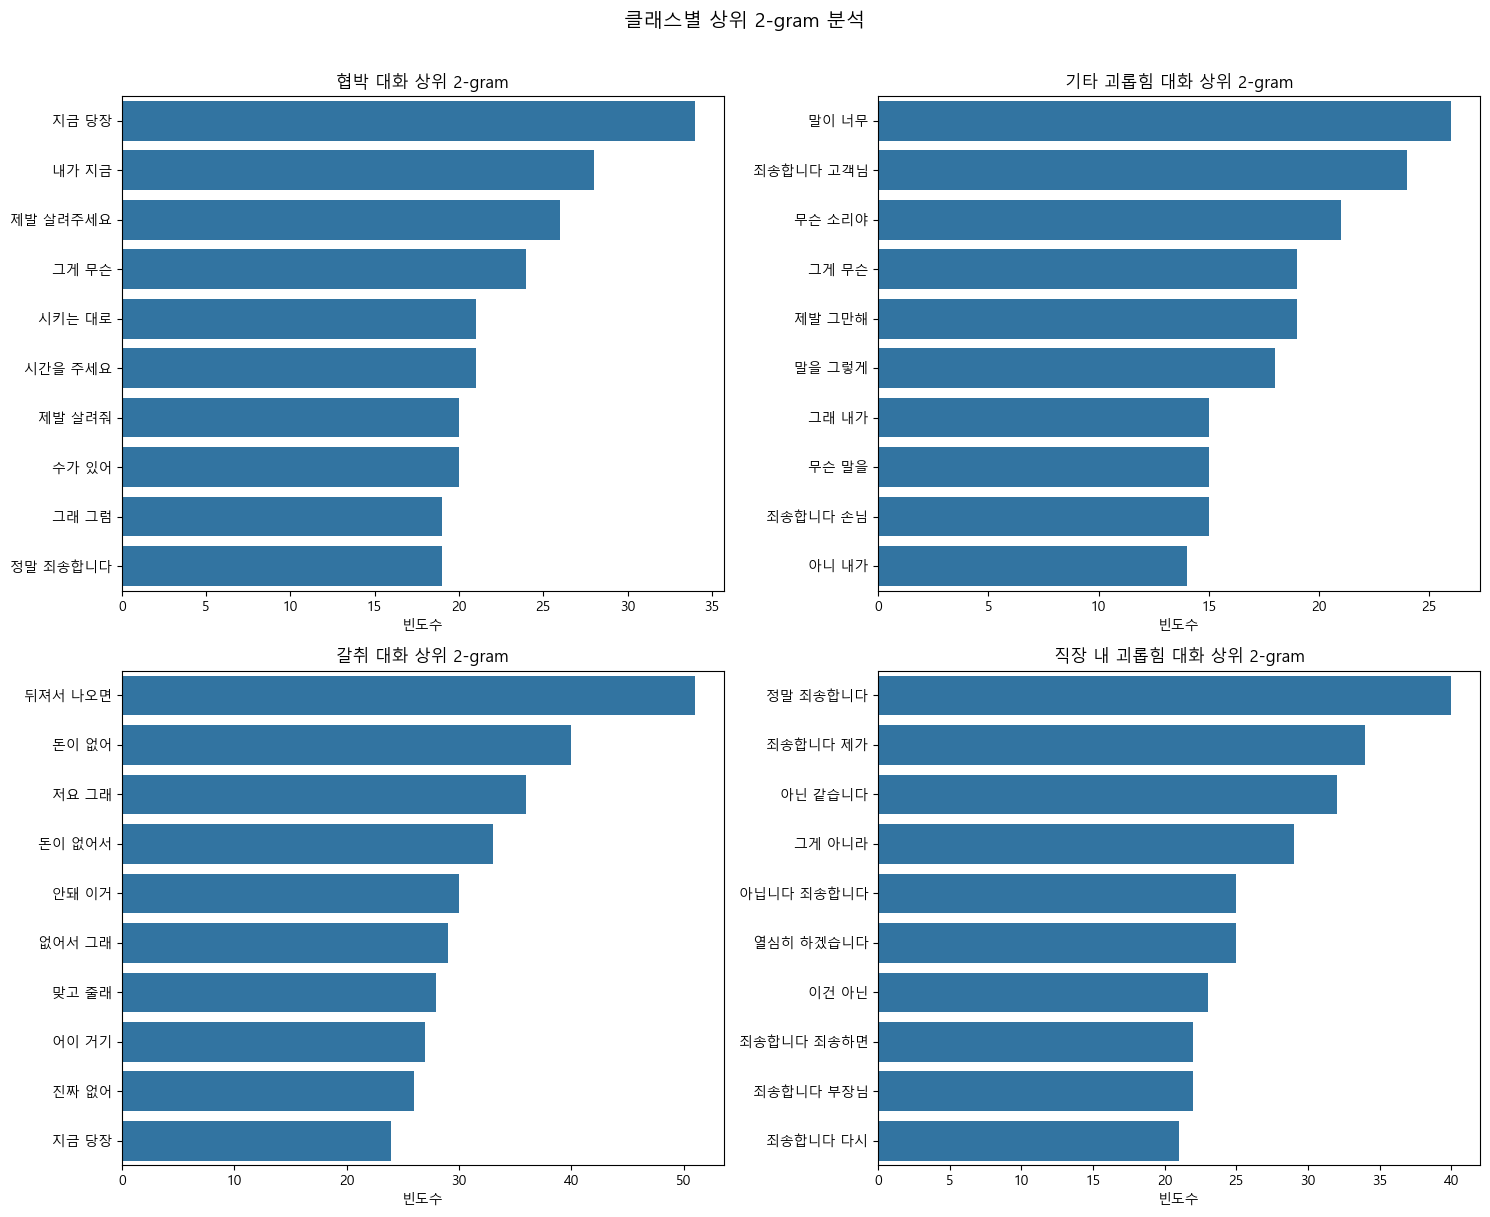


--- Tri-gram (3단어 조합) ---


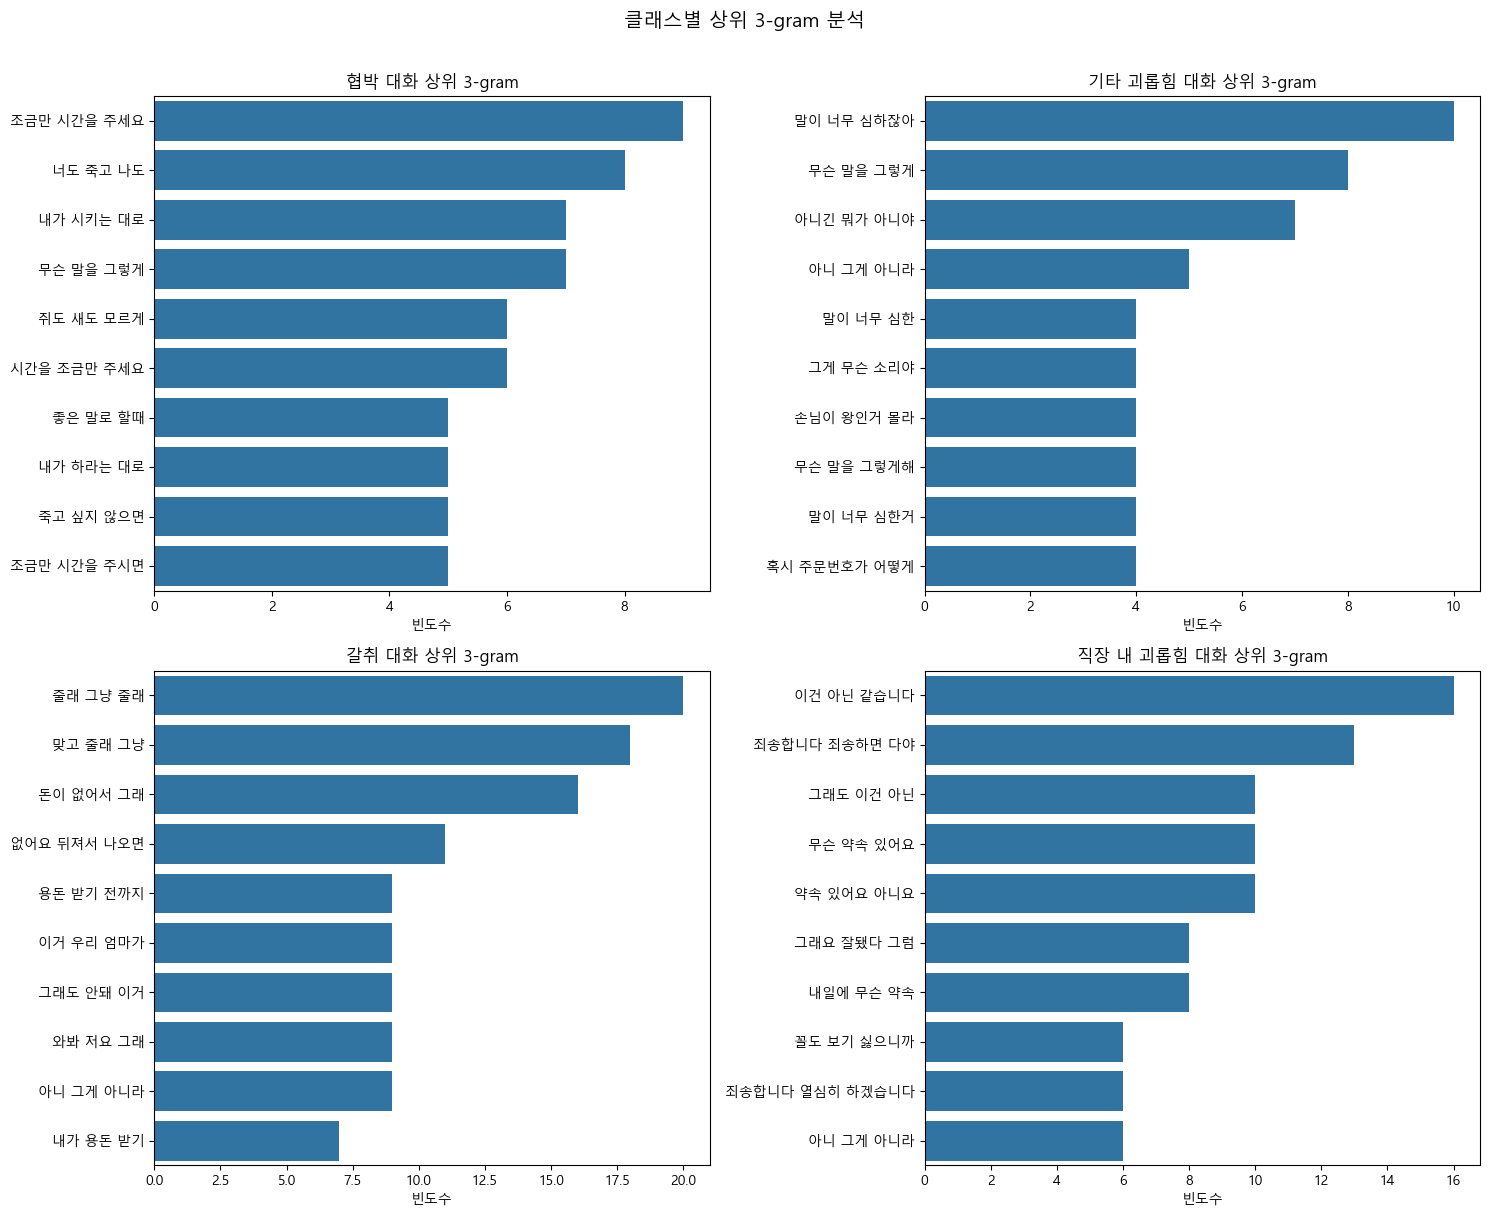


### [2-2 인사이트 및 Action Item] ###
1. '협박' 클래스에서 유독 자주 쓰이는 '도구/행위' 조합이 보이나요?
2. '직장 내 괴롭힘'에서 '상급자 호칭 + 명령조'의 조합이 어떻게 나타나는지 확인하세요.
3. 이 N-gram들을 '일반 대화' 합성 생성 시 '배제 키워드'로 활용하여 모델 변별력을 높이세요.

[2-3] 어휘 다양성 (TTR) 분석


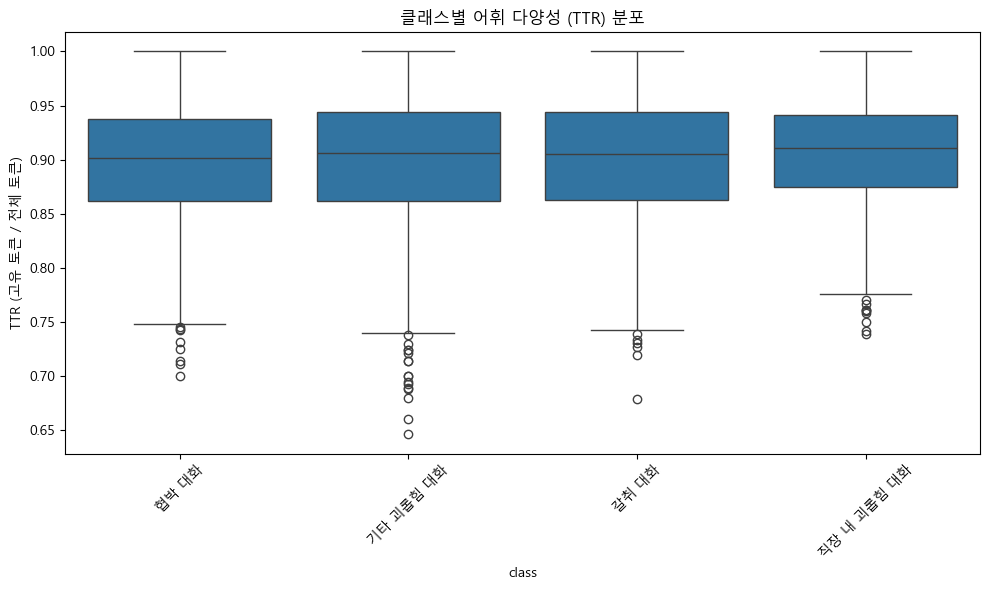


### 클래스별 TTR 통계 ###


,mean,median,std
class,,,
갈취 대화,0.901,0.906,0.058
기타 괴롭힘 대화,0.900,0.906,0.060
직장 내 괴롭힘 대화,0.907,0.911,0.050
협박 대화,0.897,0.902,0.055



### [2-3 인사이트 및 Action Item] ###
1. TTR이 낮은 클래스는 뻔한 단어만 반복 사용합니다. 증강 시 동의어 교체 폭을 넓히세요.
2. TTR이 높은 클래스는 다양한 표현이 사용됩니다. 합성 데이터도 어휘를 다양하게 구성하세요.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# ============================================================
# 2. 어휘 및 키워드 (Vocabulary) 분석
# ============================================================

# ============================================================
# [2-1] TF-IDF 상위 키워드
# eda.md: "빈도수를 넘어 해당 클래스를 '대표'하는 고유 단어 추출"
# ============================================================
def get_top_tfidf_words(df, n_top=10):
    """
    클래스별 TF-IDF 상위 키워드를 추출하는 함수
    """
    results = {}
    classes = df['class'].unique()
    class_corpus = [" ".join(df[df['class'] == c]['conversation']) for c in classes]

    vectorizer = TfidfVectorizer(max_features=1000)
    tfidf_matrix = vectorizer.fit_transform(class_corpus)
    words = vectorizer.get_feature_names_out()

    for i, class_name in enumerate(classes):
        row = tfidf_matrix.getrow(i).toarray()[0]
        top_indices = row.argsort()[-n_top:][::-1]
        results[class_name] = [words[idx] for idx in top_indices]

    return pd.DataFrame(results)

print("=" * 60)
print("[2-1] TF-IDF 상위 키워드 (클래스 대표 단어)")
print("=" * 60)
top_keywords = get_top_tfidf_words(df)
display(top_keywords)

print("\n### [2-1 인사이트 및 Action Item] ###")
print("1. 각 클래스의 TF-IDF 상위 키워드를 합성 데이터 생성 시 '반드시 포함할 단어'로 활용하세요.")
print("2. 특정 클래스에만 등장하는 고유 키워드를 다른 클래스의 합성 데이터에서 '배제할 단어'로 관리하세요.")

# ============================================================
# [2-2] N-gram 분석 (Bi-gram & Tri-gram)
# eda.md: "두 개 이상의 단어 조합 빈도 → '문맥적 패턴' 파악"
# ============================================================
def plot_top_ngrams(df, n_gram=2, top_k=10):
    """
    클래스별로 상위 n-gram을 시각화하는 함수
    """
    classes = df['class'].unique()
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i, class_name in enumerate(classes):
        corpus = df[df['class'] == class_name]['conversation']
        vec = CountVectorizer(ngram_range=(n_gram, n_gram)).fit(corpus)
        bag_of_words = vec.transform(corpus)
        sum_words = bag_of_words.sum(axis=0)
        words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

        ngram_df = pd.DataFrame(words_freq, columns=['ngram', 'count'])
        sns.barplot(x='count', y='ngram', data=ngram_df, ax=axes[i])
        axes[i].set_title(f'{class_name} 상위 {n_gram}-gram')
        axes[i].set_xlabel('빈도수')
        axes[i].set_ylabel('')

    plt.suptitle(f'클래스별 상위 {n_gram}-gram 분석', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("[2-2] N-gram 분석 (Bi-gram & Tri-gram)")
print("=" * 60)

print("\n--- Bi-gram (2단어 조합) ---")
plot_top_ngrams(df, n_gram=2)

print("\n--- Tri-gram (3단어 조합) ---")
plot_top_ngrams(df, n_gram=3)

print("\n### [2-2 인사이트 및 Action Item] ###")
print("1. '협박' 클래스에서 유독 자주 쓰이는 '도구/행위' 조합이 보이나요?")
print("2. '직장 내 괴롭힘'에서 '상급자 호칭 + 명령조'의 조합이 어떻게 나타나는지 확인하세요.")
print("3. 이 N-gram들을 '일반 대화' 합성 생성 시 '배제 키워드'로 활용하여 모델 변별력을 높이세요.")

# ============================================================
# [2-3] 어휘 다양성 (TTR: Type-Token Ratio)
# eda.md: "전체 토큰 대비 고유 토큰의 비율 → 뻔한 단어만 쓰는지 확인"
# ============================================================
def calculate_ttr(text):
    """
    Type-Token Ratio(TTR)를 계산하여 어휘 다양성 측정
    (고유 단어 수 / 전체 단어 수)
    """
    tokens = text.split()
    if len(tokens) == 0:
        return 0
    return len(set(tokens)) / len(tokens)

print("\n" + "=" * 60)
print("[2-3] 어휘 다양성 (TTR) 분석")
print("=" * 60)

df['ttr'] = df['conversation'].apply(calculate_ttr)

plt.figure(figsize=(10, 6))
sns.boxplot(x='class', y='ttr', data=df)
plt.title('클래스별 어휘 다양성 (TTR) 분포')
plt.ylabel('TTR (고유 토큰 / 전체 토큰)')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

ttr_summary = df.groupby('class')['ttr'].agg(['mean', 'median', 'std']).round(3)
print("\n### 클래스별 TTR 통계 ###")
display(ttr_summary)

print("\n### [2-3 인사이트 및 Action Item] ###")
print("1. TTR이 낮은 클래스는 뻔한 단어만 반복 사용합니다. 증강 시 동의어 교체 폭을 넓히세요.")
print("2. TTR이 높은 클래스는 다양한 표현이 사용됩니다. 합성 데이터도 어휘를 다양하게 구성하세요.")


# 3. 클래스 관계 (Semantic) 분석

이 단계에서는 모델이 분류 시 가장 헷갈려 할 '경계선(Decision Boundary)'을 파악합니다.

* **클래스 간 코사인 유사도 (Cosine Similarity)**: 각 클래스의 전체 텍스트를 하나의 거대한 문서로 간주하고 유사도를 측정합니다. 직장 내 괴롭힘과 기타 괴롭힘이 얼마나 유사한지, 협박과 갈취의 거리는 얼마나 가까운지 확인합니다.
* **단어 교집합(Word Overlap) 분석**: '돈', '너', '진짜'와 같이 여러 클래스에 동시에 등장하는 단어(Hard Negatives 유발 요소)를 추출합니다. 이 단어들의 문맥적 쓰임새를 구분하는 것이 모델 성능 향상의 핵심입니다.


[3-1] 클래스 간 코사인 유사도 분석


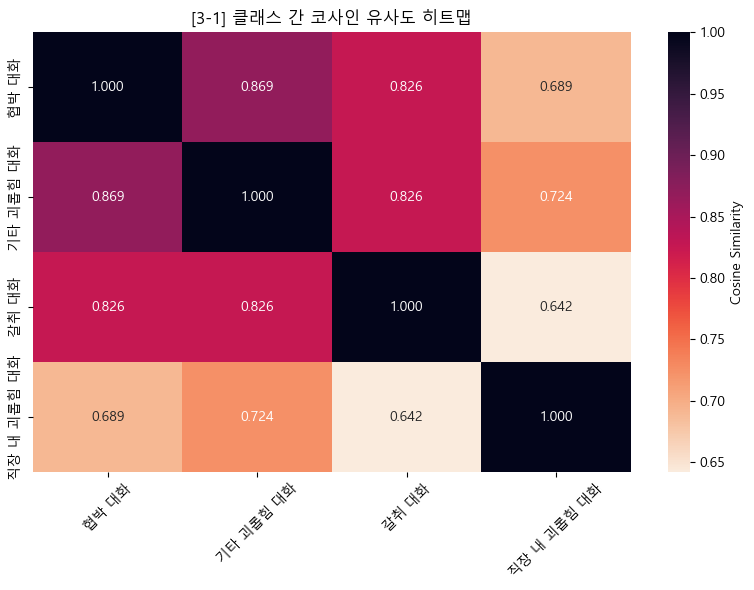


### 유사도 높은 클래스 쌍 순위 (헷갈림 위험 순) ###
  1위: [협박 대화] ↔ [기타 괴롭힘 대화] = 0.8689 ⚠️ 최우선 경계 강화 필요
  2위: [협박 대화] ↔ [갈취 대화] = 0.8262
  3위: [기타 괴롭힘 대화] ↔ [갈취 대화] = 0.8261
  4위: [기타 괴롭힘 대화] ↔ [직장 내 괴롭힘 대화] = 0.7241
  5위: [협박 대화] ↔ [직장 내 괴롭힘 대화] = 0.6893
  6위: [갈취 대화] ↔ [직장 내 괴롭힘 대화] = 0.6416

### [3-1 인사이트 및 Action Item] ###
1. 유사도가 가장 높은 클래스 쌍은 모델이 가장 많이 혼동합니다.
2. 해당 쌍 사이의 경계를 강화하는 전략(Loss 가중치, Hard Negative 학습)을 수립하세요.

[3-2] 중복 단어 (Overlap / Hard Negatives) 분석


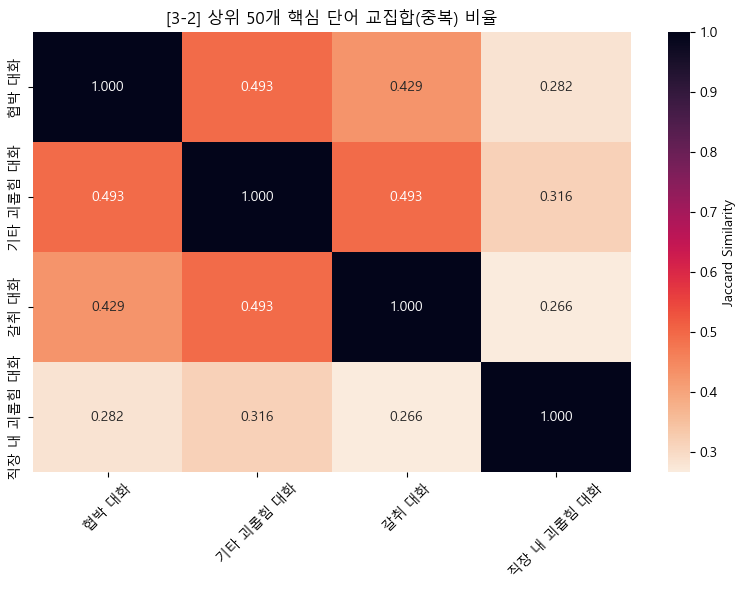


### 클래스 쌍별 공통 빈출 단어 (상위 50개 기준) ###
  [협박 대화] ↔ [기타 괴롭힘 대화] (33개): 그건, 그게, 그냥, 그래, 그럼, 그렇게, 나는, 나도, 나한테, 내가, 너가, 너무, 니가, 무슨, 미안해, 빨리, 아니, 아니야, 어떻게, 없어, 오늘, 우리, 이거, 이게, 이렇게, 이제, 있어, 정말, 제가, 제발, 죄송합니다, 지금, 진짜
  [협박 대화] ↔ [갈취 대화] (30개): 그건, 그게, 그냥, 그래, 그럼, 그렇게, 나도, 나한테, 내가, 너무, 니가, 당장, 무슨, 미안해, 빨리, 아니, 아니야, 어떻게, 없어, 오늘, 우리, 이거, 이게, 이제, 있어, 정말, 제가, 제발, 지금, 진짜
  [협박 대화] ↔ [직장 내 괴롭힘 대화] (22개): 같이, 그건, 그게, 그냥, 그래, 그럼, 그렇게, 내가, 너무, 무슨, 빨리, 아니, 어떻게, 오늘, 우리, 이거, 이렇게, 정말, 제가, 죄송합니다, 지금, 진짜
  [기타 괴롭힘 대화] ↔ [갈취 대화] (33개): 그거, 그건, 그게, 그냥, 그래, 그래도, 그럼, 그렇게, 근데, 나도, 나한테, 내가, 너무, 니가, 무슨, 미안해, 빨리, 아니, 아니야, 어떻게, 없어, 여기, 오늘, 우리, 이거, 이게, 이제, 있어, 정말, 제가, 제발, 지금, 진짜
  [기타 괴롭힘 대화] ↔ [직장 내 괴롭힘 대화] (24개): 그건, 그게, 그냥, 그래, 그래도, 그런, 그럼, 그렇게, 근데, 내가, 너무, 무슨, 빨리, 아니, 어떻게, 오늘, 우리, 이거, 이렇게, 정말, 제가, 죄송합니다, 지금, 진짜
  [갈취 대화] ↔ [직장 내 괴롭힘 대화] (21개): 그건, 그게, 그냥, 그래, 그래도, 그럼, 그렇게, 근데, 내가, 너무, 무슨, 빨리, 아니, 어떻게, 오늘, 우리, 이거, 정말, 제가, 지금, 진짜

### [3-2 인사이트 및 Action Item] ###
1. 공통 단어가 '일반 대화'에 포함되었을 때 모델이 '위협'으로 오해하지 않도록,
   공통 단

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# 3. 클래스 관계 (Semantic) 분석
# ============================================================

classes = df['class'].unique()
class_documents = [
    " ".join(df[df['class'] == cls]['conversation']) for cls in classes
]

vectorizer = TfidfVectorizer(max_features=2000)
tfidf_matrix = vectorizer.fit_transform(class_documents)
feature_names = vectorizer.get_feature_names_out()

# ============================================================
# [3-1] 클래스 간 코사인 유사도
# eda.md: "클래스별 대표 벡터 간의 거리 계산
#          → 모델이 가장 헷갈려 할 '클래스 쌍' 식별"
# ============================================================
print("=" * 60)
print("[3-1] 클래스 간 코사인 유사도 분석")
print("=" * 60)

similarity_matrix = cosine_similarity(tfidf_matrix)
similarity_df = pd.DataFrame(similarity_matrix, index=classes, columns=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(similarity_df, annot=True, cmap='rocket_r', fmt=".3f",
            cbar_kws={'label': 'Cosine Similarity'})
plt.title('[3-1] 클래스 간 코사인 유사도 히트맵')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 가장 헷갈리는 클래스 쌍 순위 출력
print("\n### 유사도 높은 클래스 쌍 순위 (헷갈림 위험 순) ###")
pairs = []
for i in range(len(classes)):
    for j in range(i + 1, len(classes)):
        pairs.append((classes[i], classes[j], similarity_matrix[i, j]))
pairs.sort(key=lambda x: -x[2])

for rank, (c1, c2, score) in enumerate(pairs, 1):
    flag = " ⚠️ 최우선 경계 강화 필요" if rank == 1 else ""
    print(f"  {rank}위: [{c1}] ↔ [{c2}] = {score:.4f}{flag}")

print("\n### [3-1 인사이트 및 Action Item] ###")
print("1. 유사도가 가장 높은 클래스 쌍은 모델이 가장 많이 혼동합니다.")
print("2. 해당 쌍 사이의 경계를 강화하는 전략(Loss 가중치, Hard Negative 학습)을 수립하세요.")

# ============================================================
# [3-2] 중복 단어 (Overlap) 분석 — Hard Negatives
# eda.md: "클래스 간 교집합 단어 및 비율 확인
#          → '돈'이 갈취와 일반 대화에 동시에 나올 때,
#            이를 구별할 '결정적 차이'를 합성 데이터에 반영"
# ============================================================
print("\n" + "=" * 60)
print("[3-2] 중복 단어 (Overlap / Hard Negatives) 분석")
print("=" * 60)

top_n = 50
class_top_words = {}
for i, cls in enumerate(classes):
    row = tfidf_matrix.getrow(i).toarray()[0]
    top_indices = row.argsort()[-top_n:][::-1]
    class_top_words[cls] = set(feature_names[idx] for idx in top_indices)

def jaccard_similarity(set1, set2):
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union else 0

overlap_matrix = np.zeros((len(classes), len(classes)))
for i, c1 in enumerate(classes):
    for j, c2 in enumerate(classes):
        overlap_matrix[i, j] = jaccard_similarity(class_top_words[c1], class_top_words[c2])

overlap_df = pd.DataFrame(overlap_matrix, index=classes, columns=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(overlap_df, annot=True, cmap='rocket_r', fmt=".3f",
            cbar_kws={'label': 'Jaccard Similarity'})
plt.title(f'[3-2] 상위 {top_n}개 핵심 단어 교집합(중복) 비율')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 실제 겹치는 단어 출력
print(f"\n### 클래스 쌍별 공통 빈출 단어 (상위 {top_n}개 기준) ###")
for i in range(len(classes)):
    for j in range(i + 1, len(classes)):
        c1, c2 = classes[i], classes[j]
        common = sorted(class_top_words[c1] & class_top_words[c2])
        if common:
            print(f"  [{c1}] ↔ [{c2}] ({len(common)}개): {', '.join(common)}")

print("\n### [3-2 인사이트 및 Action Item] ###")
print("1. 공통 단어가 '일반 대화'에 포함되었을 때 모델이 '위협'으로 오해하지 않도록,")
print("   공통 단어가 포함되었으나 무해한(Safe) 일반 대화를 합성해야 합니다. (핵심!)")
print("2. 예: '돈'이 '갈취'와 '일반 대화'에 모두 등장한다면,")
print("   '돈 빌려줘서 고마워' 같은 정상적 문맥의 합성 데이터가 필요합니다.")


# 4. 언어적 특징 (Linguistic) 분석

이 단계에서는 텍스트의 품사(POS) 분포와 형태론적 특징(존댓말, 반말, 욕설 등)을 분석하여, 각 위협 클래스만의 언어적 패턴을 파악합니다.

* **품사(POS) 분포**: 특정 클래스(예: 협박)에서 동사(명령 등)나 부정적 형용사의 비율이 높은지 확인합니다.
* **존칭/비속어 사용 빈도**: 대화의 어조(Tone)를 파악합니다. '직장 내 괴롭힘'은 존댓말('합니다', '요')이 섞여 있을 확률이 높고, '기타 괴롭힘'이나 '갈취'는 반말이나 비속어가 많을 수 있습니다.
* **전략적 활용**: 이 분석 결과는 '일반 대화' 합성 데이터 생성 시 프롬프트에 페르소나와 말투(반말/존댓말 비율)를 설정하는 핵심 지표가 됩니다.


[4-1] 품사(POS) 분포 분석
형태소 분석 중... (데이터 크기에 따라 수 분 소요될 수 있습니다)


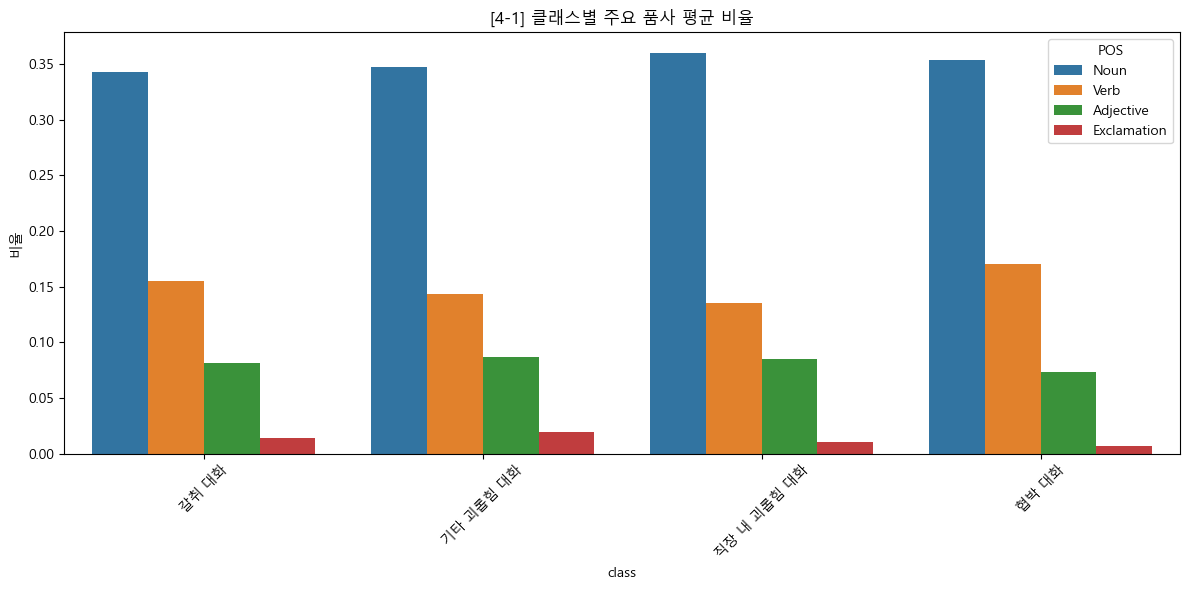


### [4-1] 클래스별 품사 비율 통계 ###


,Noun,Verb,Adjective,Exclamation
class,,,,
갈취 대화,0.3428,0.1548,0.0815,0.0139
기타 괴롭힘 대화,0.3471,0.1438,0.0865,0.0192
직장 내 괴롭힘 대화,0.3605,0.1354,0.0854,0.0105
협박 대화,0.3537,0.1702,0.0737,0.0069



### [4-1 인사이트 및 Action Item] ###
1. '협박' 클래스에 동사 비율이 높다면 → 명령조('죽여', '내놔') 말투가 특징적입니다.
2. '괴롭힘' 클래스에 형용사 비율이 높다면 → 부정적 평가('못난', '쓸모없는') 말투가 특징적입니다.
3. 감탄사 비율이 특정 클래스에 쏠려 있다면 → 합성 데이터 생성 시 감탄사 사용 빈도를 조절하세요.

[4-2] 존칭/비속어 사용 빈도 분석


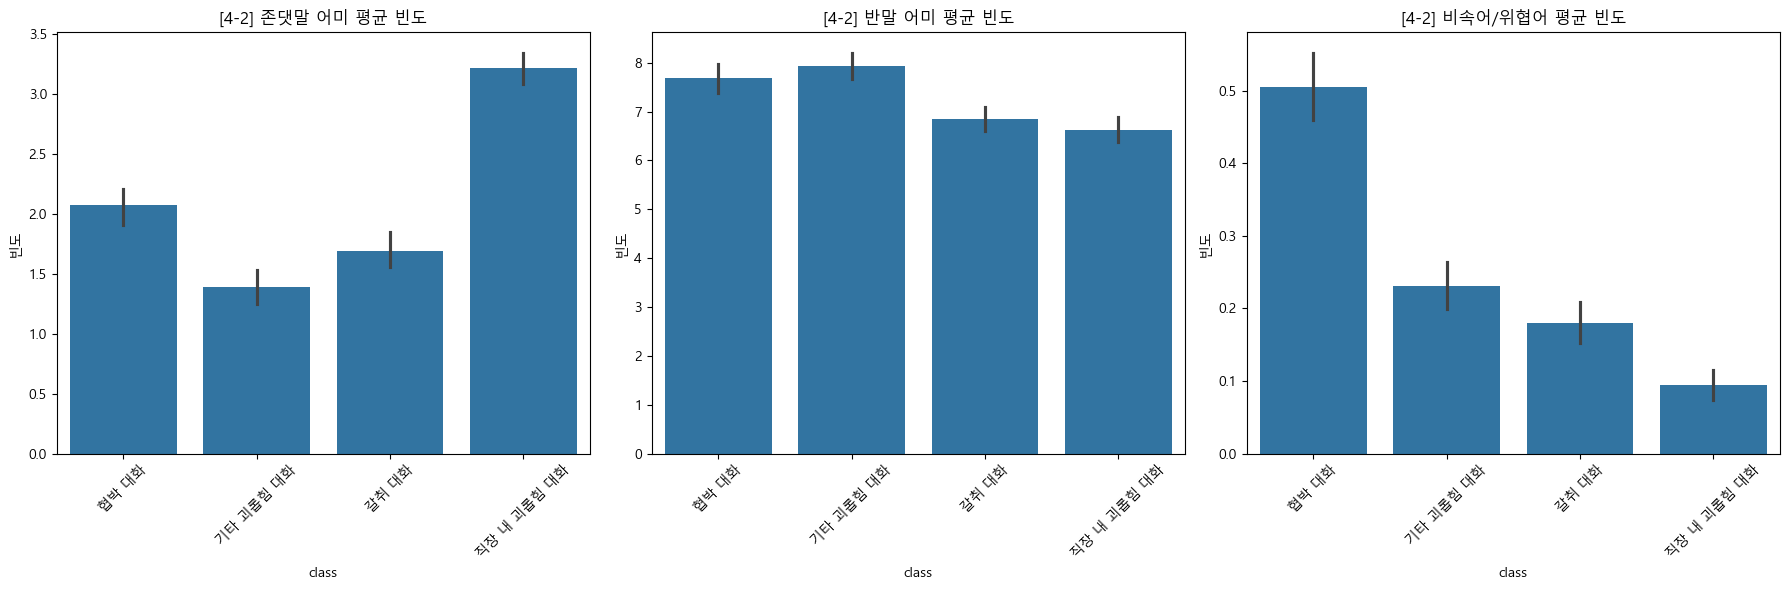


### [4-2] 클래스별 존댓말/반말/비속어 통계 ###


,polite_count,casual_count,profanity_count
class,,,
갈취 대화,1.69,6.85,0.18
기타 괴롭힘 대화,1.39,7.94,0.23
직장 내 괴롭힘 대화,3.22,6.62,0.09
협박 대화,2.07,7.68,0.51



### [4-2 인사이트 및 Action Item] ###
1. '직장 내 괴롭힘'에 존댓말 비율이 높다면 → 수직적 관계의 괴롭힘 특징입니다.
2. 욕설 빈도가 높은 클래스 확인 → 합성 데이터에 '욕설 없는 갈등 상황'을 추가하여 모델의 욕설 의존도를 낮추세요.
3. '일반 대화' 합성 시 존댓말/반말 비중을 트레인 셋의 비율과 일치시켜 이질감을 제거하세요.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

try:
    from konlpy.tag import Okt
    okt = Okt()
    USE_KONLPY = True
except ImportError:
    print("konlpy 미설치 — 형태소 분석을 건너뜁니다. (pip install konlpy)")
    USE_KONLPY = False

# ============================================================
# 4. 언어적 특징 (Linguistic) 분석
# ============================================================

# ============================================================
# [4-1] 품사(POS) 분포
# eda.md: "명사, 동사, 형용사, 감탄사의 비중 확인
#          → 협박='명령조 동사', 괴롭힘='부정적 형용사' 패턴 파악"
# ============================================================
def extract_pos_distribution(text):
    """주요 품사(명사, 동사, 형용사, 감탄사) 비율을 추출"""
    if not USE_KONLPY:
        return {'Noun': 0, 'Verb': 0, 'Adjective': 0, 'Exclamation': 0}

    pos_tags = okt.pos(text)
    pos_counts = Counter(tag for _, tag in pos_tags)
    total = len(pos_tags)
    if total == 0:
        return {'Noun': 0, 'Verb': 0, 'Adjective': 0, 'Exclamation': 0}

    return {
        'Noun': pos_counts.get('Noun', 0) / total,
        'Verb': pos_counts.get('Verb', 0) / total,
        'Adjective': pos_counts.get('Adjective', 0) / total,
        'Exclamation': pos_counts.get('Exclamation', 0) / total,
    }

print("=" * 60)
print("[4-1] 품사(POS) 분포 분석")
print("=" * 60)
print("형태소 분석 중... (데이터 크기에 따라 수 분 소요될 수 있습니다)")

if USE_KONLPY:
    pos_df = df['conversation'].apply(extract_pos_distribution).apply(pd.Series)
    df_pos = pd.concat([df[['class']], pos_df], axis=1)

    pos_summary = df_pos.groupby('class')[['Noun', 'Verb', 'Adjective', 'Exclamation']].mean().reset_index()
    pos_melted = pos_summary.melt(id_vars='class', var_name='POS', value_name='Ratio')

    plt.figure(figsize=(12, 6))
    sns.barplot(x='class', y='Ratio', hue='POS', data=pos_melted)
    plt.title('[4-1] 클래스별 주요 품사 평균 비율')
    plt.tick_params(axis='x', rotation=45)
    plt.ylabel('비율')
    plt.tight_layout()
    plt.show()

    print("\n### [4-1] 클래스별 품사 비율 통계 ###")
    display(pos_summary.set_index('class').round(4))
else:
    print("konlpy 미설치로 품사 분석을 건너뜁니다.")

print("\n### [4-1 인사이트 및 Action Item] ###")
print("1. '협박' 클래스에 동사 비율이 높다면 → 명령조('죽여', '내놔') 말투가 특징적입니다.")
print("2. '괴롭힘' 클래스에 형용사 비율이 높다면 → 부정적 평가('못난', '쓸모없는') 말투가 특징적입니다.")
print("3. 감탄사 비율이 특정 클래스에 쏠려 있다면 → 합성 데이터 생성 시 감탄사 사용 빈도를 조절하세요.")

# ============================================================
# [4-2] 존칭/비속어 사용 빈도
# eda.md: "'합니다' vs '해', 욕설/비속어의 클래스별 출현 빈도
#          → '일반 대화' 생성 시 존댓말과 반말 비중을 일치시켜 이질감 제거"
# ============================================================
def analyze_tone_and_profanity(text):
    """존댓말/반말 비율 및 비속어 사용 빈도를 분석"""
    # [존댓말 어미] — 다단어 패턴 우선 매칭
    polite_patterns = ['습니다', '합니다', '세요', '에요', '해요', '네요', '군요', '나요', '죠']
    polite_count = sum(text.count(p) for p in polite_patterns)

    # [반말 어미]
    casual_patterns = ['해', '야', '냐', '라', '거든', '잖아', '는데', '인데']
    casual_count = sum(text.count(p) for p in casual_patterns)

    # [비속어/위협어 사전]
    profanity_words = ['새끼', '미친', '죽여', '시발', '씨발', '병신', '지랄', '닥쳐', '패버릴']
    profanity_count = sum(1 for w in profanity_words if w in text)

    return pd.Series({
        'polite_count': polite_count,
        'casual_count': casual_count,
        'profanity_count': profanity_count,
    })

print("\n" + "=" * 60)
print("[4-2] 존칭/비속어 사용 빈도 분석")
print("=" * 60)

tone_df = df['conversation'].apply(analyze_tone_and_profanity)
df_tone = pd.concat([df[['class']], tone_df], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(x='class', y='polite_count', data=df_tone, ax=axes[0])
axes[0].set_title('[4-2] 존댓말 어미 평균 빈도')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('빈도')

sns.barplot(x='class', y='casual_count', data=df_tone, ax=axes[1])
axes[1].set_title('[4-2] 반말 어미 평균 빈도')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('빈도')

sns.barplot(x='class', y='profanity_count', data=df_tone, ax=axes[2])
axes[2].set_title('[4-2] 비속어/위협어 평균 빈도')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('빈도')

plt.tight_layout()
plt.show()

print("\n### [4-2] 클래스별 존댓말/반말/비속어 통계 ###")
tone_summary = df_tone.groupby('class')[['polite_count', 'casual_count', 'profanity_count']].mean().round(2)
display(tone_summary)

print("\n### [4-2 인사이트 및 Action Item] ###")
print("1. '직장 내 괴롭힘'에 존댓말 비율이 높다면 → 수직적 관계의 괴롭힘 특징입니다.")
print("2. 욕설 빈도가 높은 클래스 확인 → 합성 데이터에 '욕설 없는 갈등 상황'을 추가하여 모델의 욕설 의존도를 낮추세요.")
print("3. '일반 대화' 합성 시 존댓말/반말 비중을 트레인 셋의 비율과 일치시켜 이질감을 제거하세요.")


# 5. 품질 및 노이즈 (Quality) 분석

학습 데이터의 순도와 노이즈 수준을 점검합니다. 특수문자나 특정 부호가 모델의 예측에 결정적인 힌트(Shortcut)로 작용하지 않도록 하고, 데이터 중복 여부를 파악해 과적합(Overfitting)을 방지합니다.

* **특수문자/문장부호 빈도**: 느낌표(!), 물음표(?), 혹은 인터넷 용어(ㅋㅋ, ㅠㅠ)가 특정 클래스(예: 협박, 기타 괴롭힘)에만 집중되어 있는지 확인합니다.
* **데이터 중복**: 데이터셋 내에 완전히 동일한 대화가 있는지 확인합니다.
* **불용어(Stopwords)**: '아', '음', '어' 같은 의미 없는 추임새나 조사들이 클래스에 편향되어 있는지 살펴봅니다.


[5-1] 특수문자/문장부호 빈도 분석


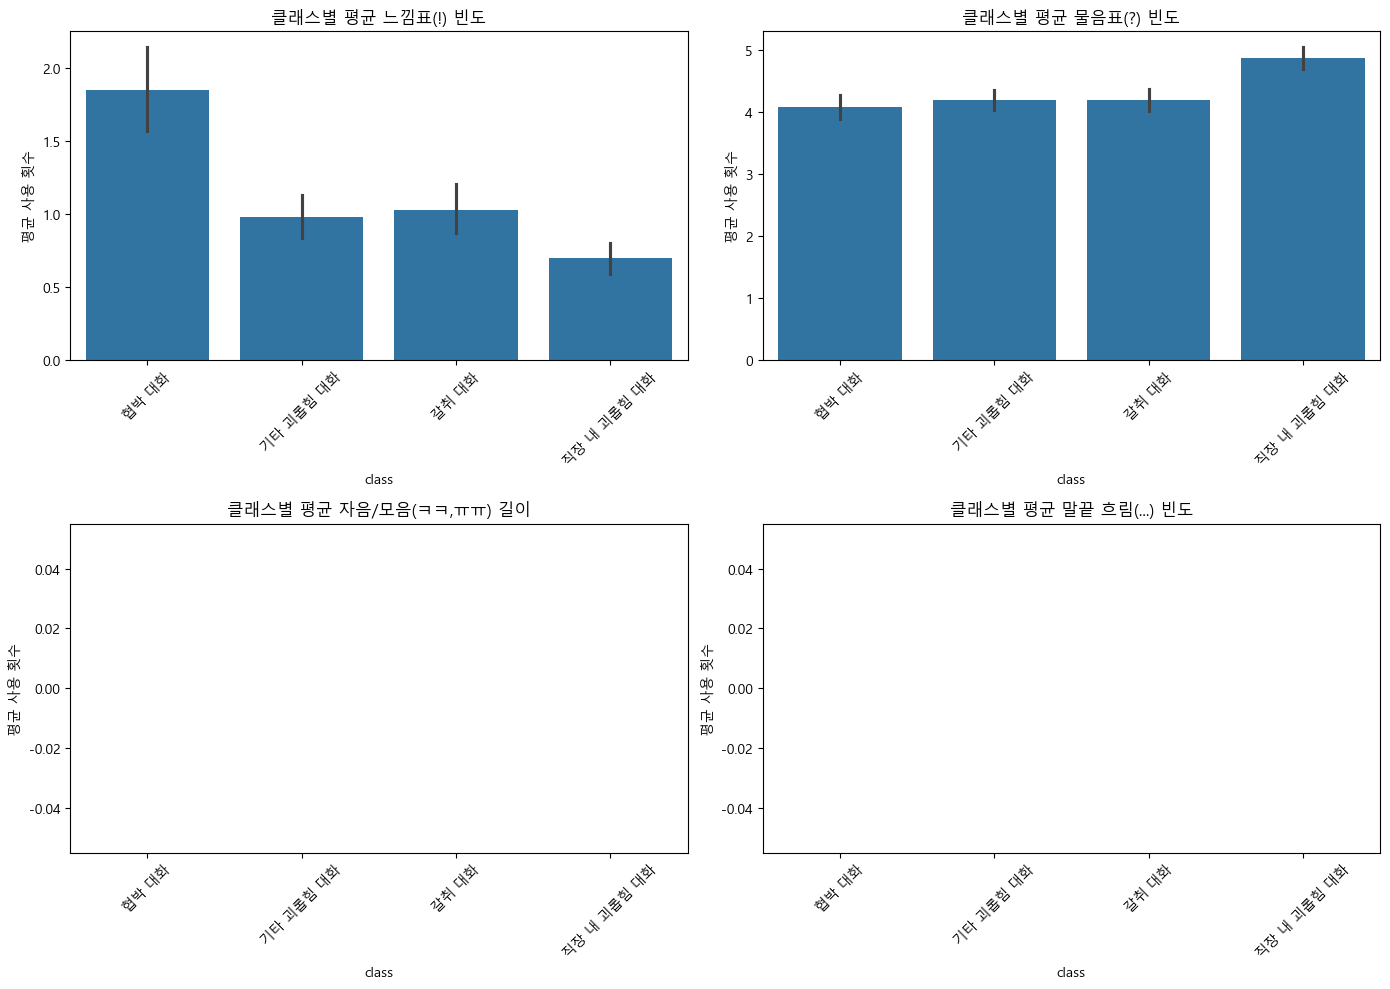


### [5-1 인사이트 및 Action Item] ###
1. 특정 클래스에만 느낌표나 말끝 흐림이 과도하게 몰려 있다면, 모델이 내용이 아닌 부호에 의존할 위험이 있습니다.
2. 학습 데이터에 'ㅋㅋ', 'ㅠㅠ'가 아예 없다면, 합성 데이터 생성 시에도 넣지 않아야 합니다.

[5-2] 데이터 중복 및 유사도 분석

[a] 완전 동일 중복 건수: 104 건
   -> 학습 시 중복 제거(deduplication)를 고려하세요.

[b] 준-중복(Near-Duplicate) 탐지 (코사인 유사도 ≥ 0.95)...
   유사도 0.95 이상인 준-중복 쌍: 117 건
   (상위 5개 예시)
   [1] idx 546 ↔ idx 2506 | 유사도: 1.0000 | 클래스: 기타 괴롭힘 대화 ↔ 기타 괴롭힘 대화
   [2] idx 796 ↔ idx 1736 | 유사도: 1.0000 | 클래스: 기타 괴롭힘 대화 ↔ 기타 괴롭힘 대화
   [3] idx 845 ↔ idx 3516 | 유사도: 1.0000 | 클래스: 갈취 대화 ↔ 갈취 대화
   [4] idx 1875 ↔ idx 2185 | 유사도: 1.0000 | 클래스: 직장 내 괴롭힘 대화 ↔ 직장 내 괴롭힘 대화
   [5] idx 3153 ↔ idx 3560 | 유사도: 1.0000 | 클래스: 기타 괴롭힘 대화 ↔ 기타 괴롭힘 대화
   -> '사실상 동일한' 데이터가 발견되었습니다. 과적합 방지를 위해 제거/통합을 고려하세요.

[5-3] 불용어(조사/기능어) 클래스별 편향 분석
클래스별 조사/기능어 빈도 추출 중...


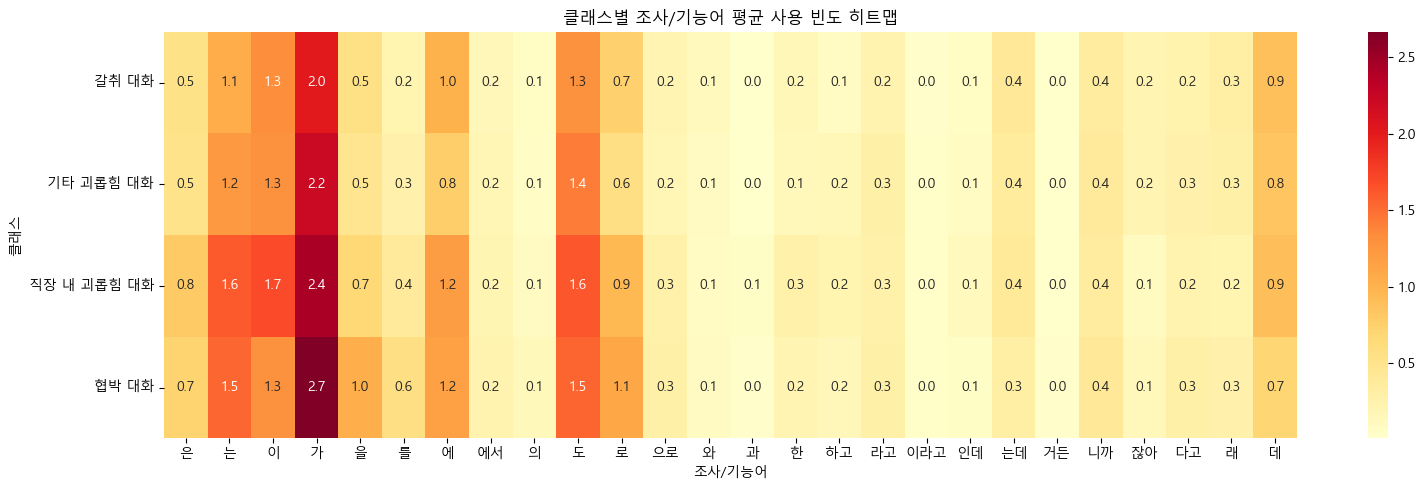


### 조사/기능어 클래스별 편향도 (변동계수 CV = std/mean) ###
(CV가 높을수록 특정 클래스에 쏠려 있어 모델이 의존할 위험이 큼)

  '과': CV = 0.697 ⚠️ 편향 주의
  '를': CV = 0.447 ⚠️ 편향 주의
  '을': CV = 0.368 ⚠️ 편향 주의
  '의': CV = 0.356 ⚠️ 편향 주의
  '하고': CV = 0.346 ⚠️ 편향 주의
  '잖아': CV = 0.319 ⚠️ 편향 주의
  '한': CV = 0.292
  '거든': CV = 0.289
  '이라고': CV = 0.282
  '인데': CV = 0.281
  '로': CV = 0.280
  '으로': CV = 0.228
  '은': CV = 0.216
  '는': CV = 0.194
  '에': CV = 0.186
  '와': CV = 0.172
  '에서': CV = 0.150
  '이': CV = 0.142
  '래': CV = 0.129
  '가': CV = 0.122
  '데': CV = 0.114
  '는데': CV = 0.112
  '다고': CV = 0.111
  '도': CV = 0.101
  '라고': CV = 0.094
  '니까': CV = 0.070

### [5-3 인사이트 및 Action Item] ###
1. CV가 높은 조사/기능어는 모델이 해당 단어에 의존해 분류할 위험이 있습니다.
2. 전처리 시 해당 기능어를 불용어 리스트에 추가하여 제거할지, 그대로 둘지 결정하세요.
3. 합성 데이터 생성 시, 클래스별 조사 빈도를 트레인 셋과 유사하게 맞추면 이질감을 줄일 수 있습니다.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# 5. 품질 및 노이즈 (Quality) 분석
# ============================================================
# 이 셀에서는 eda.md 카테고리 5의 3가지 세부 지표를 분석합니다.
# 5-1. 특수문자/문장부호 빈도
# 5-2. 데이터 중복 및 유사도
# 5-3. 불용어(Stopwords) 분석 — 조사/기능어의 클래스별 편향

# ============================================================
# [5-1] 특수문자/문장부호 빈도
# ============================================================
def analyze_noise_features(text):
    """
    텍스트 내의 특수문자, 문장부호, 감정 표현 자음/모음 빈도를 추출합니다.
    """
    exclamation_count = text.count('!')
    question_count = text.count('?')

    emoticon_pattern = re.compile(r'[ㅋㅎㅠㅜ]+')
    emoticons = emoticon_pattern.findall(text)
    emoticon_len = sum(len(e) for e in emoticons)

    ellipsis_count = len(re.findall(r'\.{2,}', text))

    return pd.Series({
        'exclamation_count': exclamation_count,
        'question_count': question_count,
        'emoticon_len': emoticon_len,
        'ellipsis_count': ellipsis_count,
    })

print("="*60)
print("[5-1] 특수문자/문장부호 빈도 분석")
print("="*60)

noise_df = df['conversation'].apply(analyze_noise_features)
df_noise = pd.concat([df[['class', 'conversation']], noise_df], axis=1)

features_to_plot = ['exclamation_count', 'question_count', 'emoticon_len', 'ellipsis_count']
titles = ['느낌표(!) 빈도', '물음표(?) 빈도', '자음/모음(ㅋㅋ,ㅠㅠ) 길이', '말끝 흐림(...) 빈도']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (feature, title) in enumerate(zip(features_to_plot, titles)):
    sns.barplot(x='class', y=feature, data=df_noise, ax=axes[i])
    axes[i].set_title(f'클래스별 평균 {title}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('평균 사용 횟수')

plt.tight_layout()
plt.show()

print("\n### [5-1 인사이트 및 Action Item] ###")
print("1. 특정 클래스에만 느낌표나 말끝 흐림이 과도하게 몰려 있다면, 모델이 내용이 아닌 부호에 의존할 위험이 있습니다.")
print("2. 학습 데이터에 'ㅋㅋ', 'ㅠㅠ'가 아예 없다면, 합성 데이터 생성 시에도 넣지 않아야 합니다.")

# ============================================================
# [5-2] 데이터 중복 및 유사도
# ============================================================
print("\n" + "="*60)
print("[5-2] 데이터 중복 및 유사도 분석")
print("="*60)

# --- (a) 완전 중복 탐지 ---
duplicated_rows = df.duplicated(subset=['conversation'])
num_duplicates = duplicated_rows.sum()
print(f"\n[a] 완전 동일 중복 건수: {num_duplicates} 건")
if num_duplicates > 0:
    print("   -> 학습 시 중복 제거(deduplication)를 고려하세요.")
else:
    print("   -> 완전 중복은 없습니다.")

# --- (b) 준-중복(Near-Duplicate) 탐지: 코사인 유사도 ---
print("\n[b] 준-중복(Near-Duplicate) 탐지 (코사인 유사도 ≥ 0.95)...")
tfidf = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['conversation'])
sim_matrix = cosine_similarity(tfidf_matrix)

# 대각선(자기 자신) 제거 후 상삼각 행렬만 검사
np.fill_diagonal(sim_matrix, 0)
near_dup_pairs = []
threshold = 0.95
rows, cols = np.where(np.triu(sim_matrix) >= threshold)
for r, c in zip(rows, cols):
    near_dup_pairs.append((r, c, sim_matrix[r, c]))

print(f"   유사도 {threshold} 이상인 준-중복 쌍: {len(near_dup_pairs)} 건")
if len(near_dup_pairs) > 0:
    print(f"   (상위 5개 예시)")
    for idx, (r, c, score) in enumerate(sorted(near_dup_pairs, key=lambda x: -x[2])[:5]):
        print(f"   [{idx+1}] idx {r} ↔ idx {c} | 유사도: {score:.4f} | 클래스: {df.iloc[r]['class']} ↔ {df.iloc[c]['class']}")
    print("   -> '사실상 동일한' 데이터가 발견되었습니다. 과적합 방지를 위해 제거/통합을 고려하세요.")
else:
    print("   -> 준-중복 데이터가 없습니다.")

# ============================================================
# [5-3] 불용어(Stopwords) — 조사/기능어 클래스별 편향 분석
# ============================================================
print("\n" + "="*60)
print("[5-3] 불용어(조사/기능어) 클래스별 편향 분석")
print("="*60)

# 한국어 주요 조사 및 기능어 리스트
# eda.md: "모델이 '을/를' 같은 조사에 의존하지 않도록 불용어 처리 수위 조절"
stopwords_list = [
    '은', '는', '이', '가', '을', '를', '에', '에서', '의', '도',
    '로', '으로', '와', '과', '한', '하고', '라고', '이라고',
    '인데', '는데', '거든', '니까', '잖아', '다고', '래', '데',
]

def count_stopwords(text, stopwords):
    """
    공백 기준 split 후 각 조사/기능어가 토큰의 끝에 붙어있는 빈도를 측정합니다.
    (한국어에서 조사는 체언 뒤에 붙으므로 endswith 패턴 사용)
    """
    tokens = text.split()
    counts = {}
    for sw in stopwords:
        cnt = sum(1 for t in tokens if t.endswith(sw) and len(t) > len(sw))
        counts[sw] = cnt
    return pd.Series(counts)

print("클래스별 조사/기능어 빈도 추출 중...")
sw_counts = df['conversation'].apply(lambda x: count_stopwords(x, stopwords_list))
df_sw = pd.concat([df[['class']], sw_counts], axis=1)

# 클래스별 평균 빈도
sw_summary = df_sw.groupby('class')[stopwords_list].mean()

# 시각화: 히트맵
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(sw_summary, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('클래스별 조사/기능어 평균 사용 빈도 히트맵')
ax.set_ylabel('클래스')
ax.set_xlabel('조사/기능어')
plt.tight_layout()
plt.show()

# 편향 분석: 특정 기능어가 특정 클래스에만 쏠린 정도 (변동계수 CV 사용)
print("\n### 조사/기능어 클래스별 편향도 (변동계수 CV = std/mean) ###")
cv_scores = sw_summary.std() / sw_summary.mean()
cv_scores = cv_scores.sort_values(ascending=False)
print("(CV가 높을수록 특정 클래스에 쏠려 있어 모델이 의존할 위험이 큼)\n")
for sw, cv in cv_scores.items():
    flag = " ⚠️ 편향 주의" if cv > 0.3 else ""
    print(f"  '{sw}': CV = {cv:.3f}{flag}")

print("\n### [5-3 인사이트 및 Action Item] ###")
print("1. CV가 높은 조사/기능어는 모델이 해당 단어에 의존해 분류할 위험이 있습니다.")
print("2. 전처리 시 해당 기능어를 불용어 리스트에 추가하여 제거할지, 그대로 둘지 결정하세요.")
print("3. 합성 데이터 생성 시, 클래스별 조사 빈도를 트레인 셋과 유사하게 맞추면 이질감을 줄일 수 있습니다.")


# 6. 상황 및 맥락 (Context & Flow) 분석

텍스트가 가진 고유의 '무대(안/밖, 회사/학교)'와 '대화의 기승전결 흐름'을 뜯어봅니다.

* **도메인(Context) 키워드 쏠림 분석**: '대리, 팀장, 출근' 같은 특정 상황 관련 단어들이 '직장 내 괴롭힘' 클래스에만 지나치게 몰려 있는지 확인합니다. 만약 그렇다면, 모델은 "회사 관련 단어 = 직장 내 괴롭힘"으로 단순 암기할 우려가 있습니다.
* **대화의 전개 양상 (Flow 분석)**: 발화의 순서(초반 -> 중반 -> 후반)에 따라 위협 강도나 공격적인 단제가 어떻게 변하는지 확인합니다. 이는 처음엔 일상 대화 같다가 끝에 돌변하는 '고난도 합성 데이터 시나리오'를 설계하는 밑거름이 됩니다.


[6-1] 도메인 별 키워드 쏠림 분석


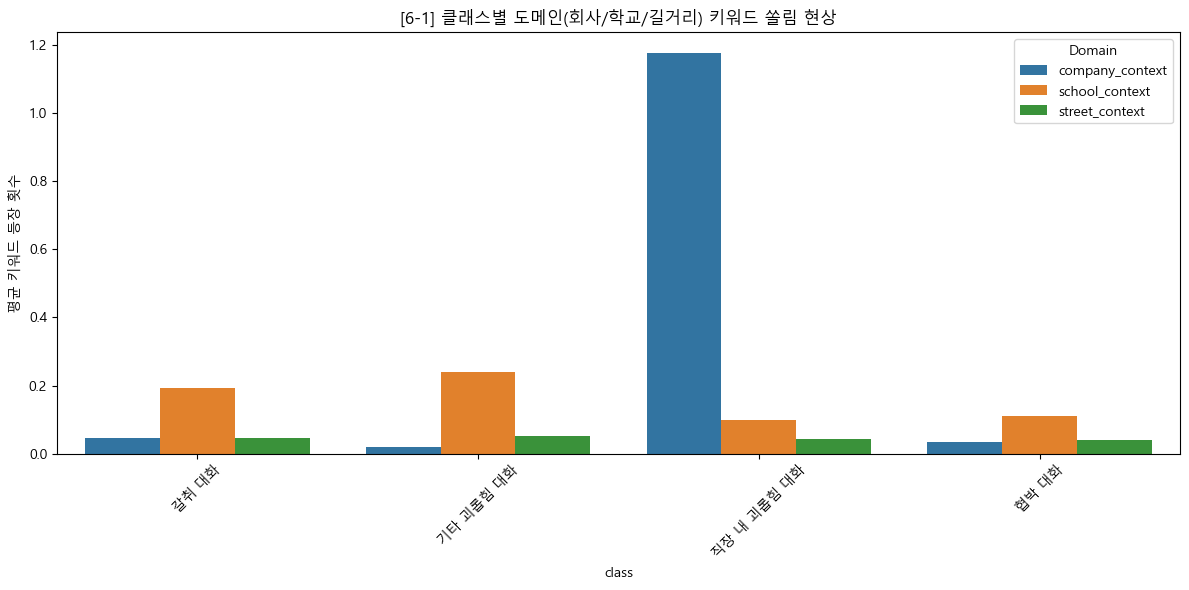


### [6-1] 클래스별 도메인 키워드 통계 ###


,company_context,school_context,street_context
class,,,
갈취 대화,0.047,0.192,0.047
기타 괴롭힘 대화,0.019,0.239,0.051
직장 내 괴롭힘 대화,1.179,0.100,0.042
협박 대화,0.033,0.112,0.041



### [6-1 인사이트 및 Action Item] ###
1. '직장 내 괴롭힘'에만 회사 단어가 쏠려 있다면, 모델이 '대리님'만 보고 괴롭힘으로 분류할 수 있습니다.
2. 이를 방지하기 위해 '대리님, 이번 결재 건 관련해서...' 같은 정상적인 직장 일상 대화를 합성 데이터로 반드시 생성하세요.
3. 학교/길거리 도메인도 동일한 원리로, 해당 키워드가 포함된 무해한 일반 대화를 설계해야 합니다.

[6-2] 발화 순서별 감정/의도 변화 분석


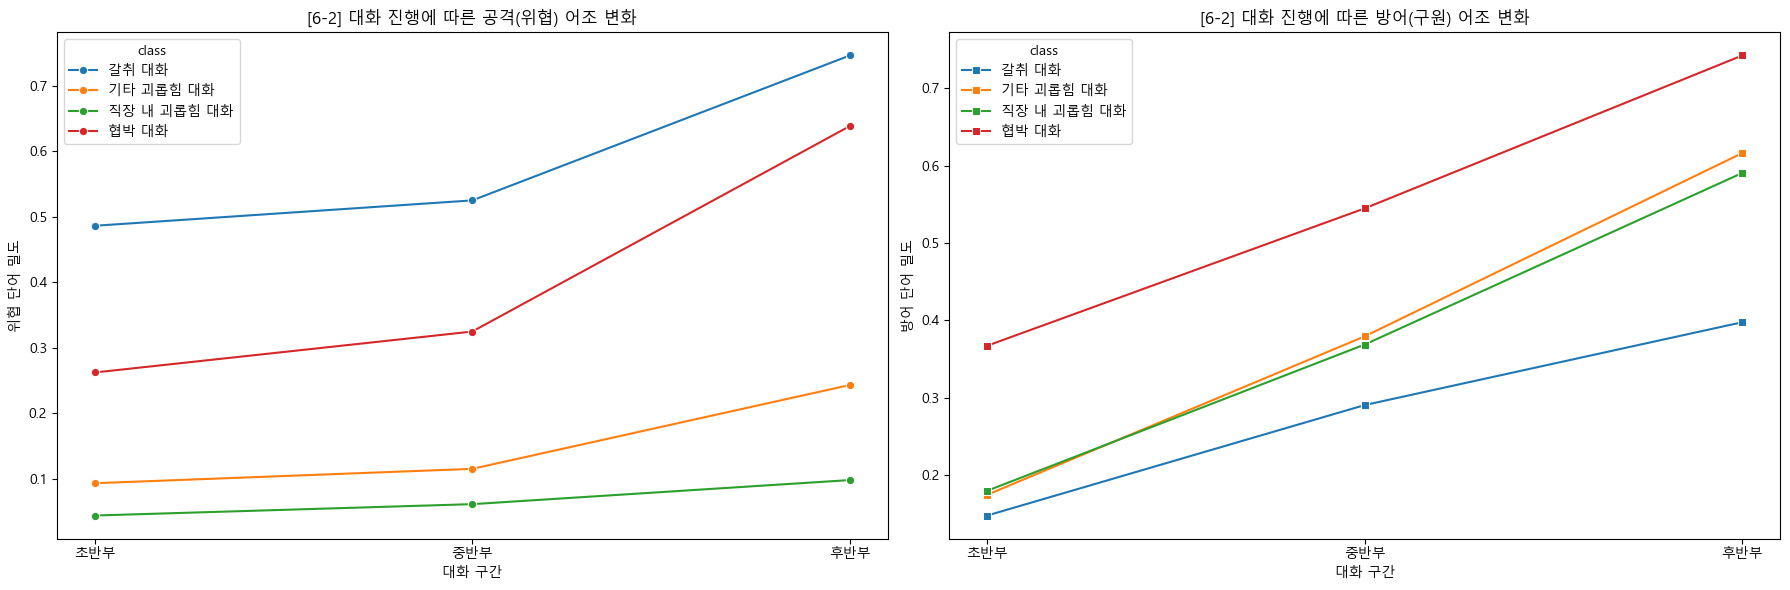


### [6-2 인사이트 및 Action Item] ###
1. 위협이 초반부터 강하다면 → '직접 협박' 패턴입니다.
2. 후반으로 갈수록 위협이 짙어진다면 → '간접 협박' 또는 '갈취' 패턴입니다.
3. 방어 단어가 후반에 급증한다면 → 피해자의 반응 패턴으로, 합성 데이터에 이 흐름을 반영하세요.
4. 처음엔 친절하다가 마지막에 위협적으로 변하는 '간접 협박' 시나리오를 증강 전략에 포함하세요.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 6. 상황 및 맥락 (Context & Flow) 분석
# ============================================================

# ============================================================
# [6-1] 도메인 별 키워드 쏠림 분석
# eda.md: "특정 장소(회사, 학교, 길거리) 관련 단어와 클래스 간 상관관계
#          → '회사' 단어 → 무조건 '직장 괴롭힘' 분류 편향 방지"
# ============================================================
def analyze_domain_context(text):
    """도메인(장소/상황) 관련 키워드 등장 여부를 확인"""
    company_words = ['회사', '팀장', '과장', '대리', '사원', '업무', '결재', '출근', '퇴근', '회의']
    school_words = ['학교', '선생', '학생', '교실', '공부', '성적', '숙제', '학원', '수업', '점수']
    street_words = ['골목', '길거리', '거리', '공원', '편의점', '술집', '노래방', '클럽', '카페', '지하철']

    return pd.Series({
        'company_context': sum(1 for w in company_words if w in text),
        'school_context': sum(1 for w in school_words if w in text),
        'street_context': sum(1 for w in street_words if w in text),
    })

print("=" * 60)
print("[6-1] 도메인 별 키워드 쏠림 분석")
print("=" * 60)

domain_df = df['conversation'].apply(analyze_domain_context)
df_domain = pd.concat([df[['class']], domain_df], axis=1)

domain_summary = df_domain.groupby('class')[['company_context', 'school_context', 'street_context']].mean().reset_index()
domain_melted = domain_summary.melt(id_vars='class', var_name='Domain', value_name='Average Keywords')

plt.figure(figsize=(12, 6))
sns.barplot(x='class', y='Average Keywords', hue='Domain', data=domain_melted)
plt.title('[6-1] 클래스별 도메인(회사/학교/길거리) 키워드 쏠림 현상')
plt.tick_params(axis='x', rotation=45)
plt.ylabel('평균 키워드 등장 횟수')
plt.tight_layout()
plt.show()

print("\n### [6-1] 클래스별 도메인 키워드 통계 ###")
display(domain_summary.set_index('class').round(3))

print("\n### [6-1 인사이트 및 Action Item] ###")
print("1. '직장 내 괴롭힘'에만 회사 단어가 쏠려 있다면, 모델이 '대리님'만 보고 괴롭힘으로 분류할 수 있습니다.")
print("2. 이를 방지하기 위해 '대리님, 이번 결재 건 관련해서...' 같은 정상적인 직장 일상 대화를 합성 데이터로 반드시 생성하세요.")
print("3. 학교/길거리 도메인도 동일한 원리로, 해당 키워드가 포함된 무해한 일반 대화를 설계해야 합니다.")

# ============================================================
# [6-2] 발화 순서별 감정/의도 변화
# eda.md: "대화 초반/중반/후반의 어조 변화 및 공수(공격/방어) 교대 패턴
#          → 처음엔 친절 → 마지막에 위협 '간접 협박' 시나리오 보강"
# ============================================================
def analyze_conversation_flow(text):
    """대화 초/중/후반부의 위협 단어 밀도 및 공수 패턴 변화를 측정"""
    threat_words = ['죽여', '맞을래', '돈', '내놔', '닥쳐', '미친', '새끼', '씨발', '경찰', '신고', '죽어']
    defense_words = ['살려', '제발', '그만', '왜요', '미안', '죄송', '잘못', '용서', '하지마', '싫어']

    turns = [t.strip() for t in text.split('\n') if t.strip()]
    total_turns = len(turns)

    if total_turns < 3:
        return pd.Series({
            'threat_early': 0, 'threat_mid': 0, 'threat_late': 0,
            'defense_early': 0, 'defense_mid': 0, 'defense_late': 0,
        })

    chunk = total_turns // 3
    sections = [
        " ".join(turns[:chunk]),
        " ".join(turns[chunk:chunk * 2]),
        " ".join(turns[chunk * 2:]),
    ]

    result = {}
    for idx, label in enumerate(['early', 'mid', 'late']):
        result[f'threat_{label}'] = sum(1 for w in threat_words if w in sections[idx])
        result[f'defense_{label}'] = sum(1 for w in defense_words if w in sections[idx])

    return pd.Series(result)

print("\n" + "=" * 60)
print("[6-2] 발화 순서별 감정/의도 변화 분석")
print("=" * 60)

flow_df = df['conversation'].apply(analyze_conversation_flow)
df_flow = pd.concat([df[['class']], flow_df], axis=1)

# --- 시각화 1: 위협 어조 흐름 ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

threat_summary = df_flow.groupby('class')[['threat_early', 'threat_mid', 'threat_late']].mean().reset_index()
threat_melted = threat_summary.melt(id_vars='class', var_name='Phase', value_name='Intensity')
threat_melted['Phase'] = threat_melted['Phase'].map({
    'threat_early': '초반부', 'threat_mid': '중반부', 'threat_late': '후반부'
})

sns.lineplot(x='Phase', y='Intensity', hue='class', marker='o', data=threat_melted, ax=axes[0])
axes[0].set_title('[6-2] 대화 진행에 따른 공격(위협) 어조 변화')
axes[0].set_ylabel('위협 단어 밀도')
axes[0].set_xlabel('대화 구간')

# --- 시각화 2: 방어 어조 흐름 ---
defense_summary = df_flow.groupby('class')[['defense_early', 'defense_mid', 'defense_late']].mean().reset_index()
defense_melted = defense_summary.melt(id_vars='class', var_name='Phase', value_name='Intensity')
defense_melted['Phase'] = defense_melted['Phase'].map({
    'defense_early': '초반부', 'defense_mid': '중반부', 'defense_late': '후반부'
})

sns.lineplot(x='Phase', y='Intensity', hue='class', marker='s', data=defense_melted, ax=axes[1])
axes[1].set_title('[6-2] 대화 진행에 따른 방어(구원) 어조 변화')
axes[1].set_ylabel('방어 단어 밀도')
axes[1].set_xlabel('대화 구간')

plt.tight_layout()
plt.show()

print("\n### [6-2 인사이트 및 Action Item] ###")
print("1. 위협이 초반부터 강하다면 → '직접 협박' 패턴입니다.")
print("2. 후반으로 갈수록 위협이 짙어진다면 → '간접 협박' 또는 '갈취' 패턴입니다.")
print("3. 방어 단어가 후반에 급증한다면 → 피해자의 반응 패턴으로, 합성 데이터에 이 흐름을 반영하세요.")
print("4. 처음엔 친절하다가 마지막에 위협적으로 변하는 '간접 협박' 시나리오를 증강 전략에 포함하세요.")
